In [26]:
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
import numpy as np

def naca_4digit(string : str, n : int, alpha : float = 0, position_of_center : np.ndarray = np.array([0.5,0])) -> np.ndarray:
    """
    Returns the airfoil camber line and thickness distribution.
    Parameters
    ----------
    string : str
        A string consisting of 4 integers like "0012". This is the "name" of the airfoil
    n : int
        The number of points you want to modulate the airfoil with
    """

    # Raise error if name of NACA-airfoil is not 4 long
    if len(string) != 4:
        raise IndexError("The string needs to have the length 4")
    
    # Fetch information from the name of the airfoil
    m = int(string[0])/100
    p = int(string[1])/10 if string[1] != "0" else 0.1
    t = int(string[2] + string[3])/100

    # If an equal amount of nodes is used to approximate the airfoil
    if (n//2)*2 == n:

        # Create a linspace with points spaced equally between 0 and pi for the upper and lower surface of the airfoil
        beta = np.linspace(0,np.pi,(n//2)+1)

        # Convert this linspace to an array with points that are the most concentrated at the edges of the airfoil.
        x = (1-np.cos(beta))/2

        # Define the thickness of the airfoil distrebution in terms of x
        yt = 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1036 * x**4)

        # Define the camber in terms of x
        yc = np.where(x < p, m/p**2 * (2*p*x - x**2), m/(1-p)**2 * ((1-2*p) + 2*p*x - x**2))

        # Create the lower and upper part of the airfoil
        lower = np.hstack((x.reshape(-1,1), (yc - yt).reshape(-1,1)))[::-1][:-1]
        upper = np.hstack((x.reshape(-1,1), (yc + yt).reshape(-1,1)))[:-1]

    # If an odd amount of nodes is used to approximate the airfoil
    elif (n//2)*2 != n:

        # Create a linspace with points spaced equally between 0 and pi for the lower surface of the airfoil with one more point than for the upper part
        beta = np.linspace(0,np.pi,(n//2)+1)

        # Convert this linspace to an array with points that are the most concentrated at the edges of the airfoil.
        x = (1-np.cos(beta))/2
        
        # Define the thickness of the airfoil distrebution in terms of x
        yt = 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1036 * x**4)

        # Define the camber in terms of x
        yc = np.where(x < p, m/p**2 * (2*p*x - x**2), m/(1-p)**2 * ((1-2*p) + 2*p*x - x**2))

        # Define the lower part of the airfoil
        lower = np.hstack((x.reshape(-1,1), (yc - yt).reshape(-1,1)))[::-1][:-1]

        # Create a linspace with points spaced equally between 0 and pi for the upper surface of the airfoil
        beta = np.linspace(0,np.pi,(n//2)+2)

        # Convert this linspace to an array with points that are the most concentrated at the edges of the airfoil.
        x = (1-np.cos(beta))/2
        
        # Define the thickness of the airfoil distrebution in terms of x
        yt = 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1036 * x**4)

        # Define the camber in terms of x
        yc = np.where(x < p, m/p**2 * (2*p*x - x**2), m/(1-p)**2 * ((1-2*p) + 2*p*x - x**2))

        # Define the upper part of the airfoil
        upper = np.hstack((x.reshape(-1,1), (yc + yt).reshape(-1,1)))[:-1]
    
    # Stack the points of the lower surface on top of the points from the upper surface
    points = np.vstack((lower, upper))

    # Relocate the airfoil such that it haves its center at the origin
    points -= np.array([0.5,0])

    # Rotate the airfoil
    alpha = np.deg2rad(alpha)
    rot_matrix = np.array([[np.cos(alpha), -np.sin(alpha)], [np.sin(alpha), np.cos(alpha)]])
    points = np.dot(points, rot_matrix)

    # Relocate the airfoil such that it haves its center as desired
    points += position_of_center

    # Return points defining the airfoil
    return points

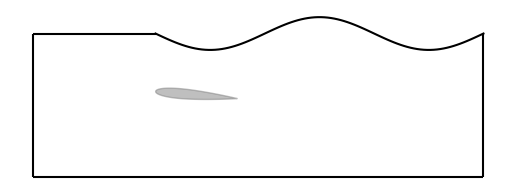

In [148]:
fig, ax = plt.subplots()
points = naca_4digit("0012", 200, alpha=5)
xlim = (-1.5,4)
ylim = (-1,0.75)

# Box lines
ax.vlines(xlim, *ylim, color="k")
ax.hlines(ylim[0], *xlim, color = "k")

# Airfoil
ax.fill(points[:, 0], points[:, 1], alpha=0.5, c = "grey")

# Surface
wave_start = 0
fsx = np.linspace(wave_start,4,100)
T = 1.5*(2*np.pi)/(xlim[1]-wave_start)

ax.hlines(ylim[1],*(xlim[0], wave_start), color = "k")
ax.plot(fsx, -0.2*(np.sin(T*(fsx-wave_start))) + ylim[1], color = "k")


ax.set_aspect("equal", adjustable="box")
ax.set_axis_off()
plt.show()


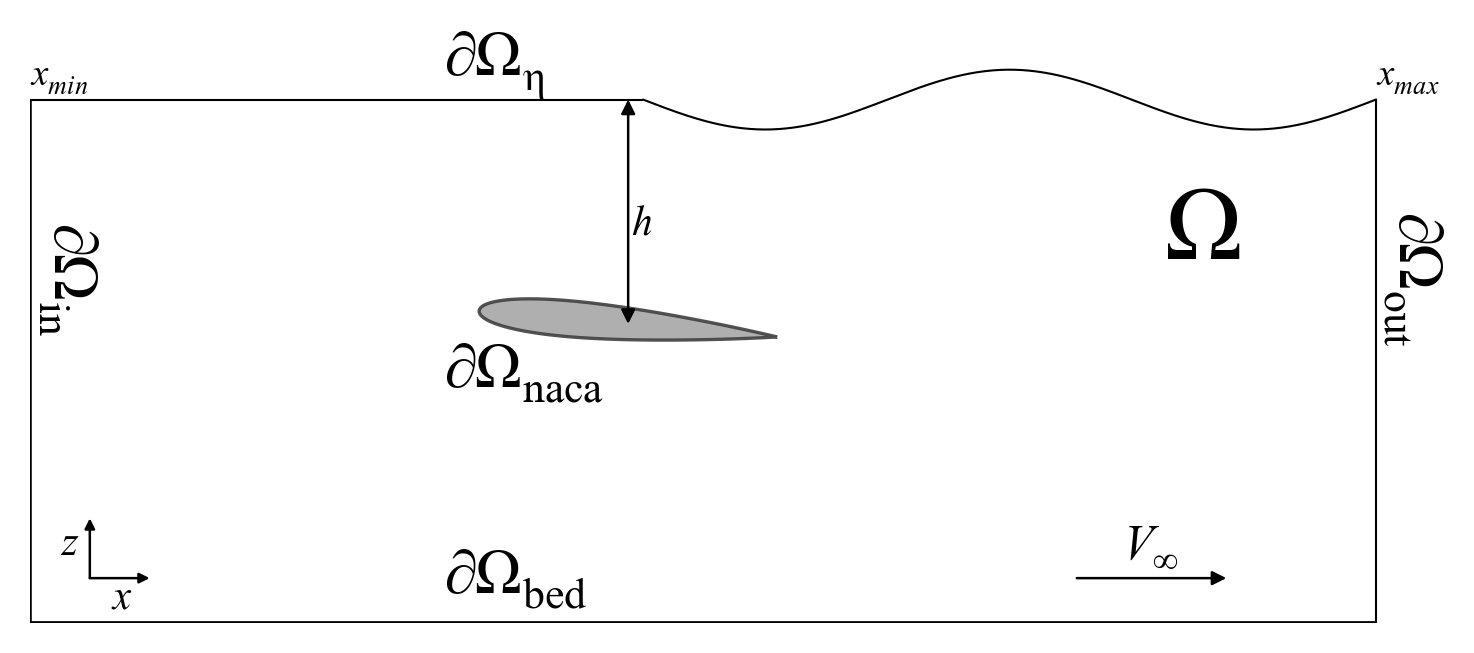

In [450]:
import numpy as np
import matplotlib.pyplot as plt

def plot_model_sketch(alpha_deg=5, n_points=200,
                      xlim=(-1.5, 3.0), ylim=(-1.0, 0.75),
                      wave_start=0.55, wave_amp=0.1, wave_offset=0.0,
                      savepath=".", position_of_center = (0.5,0)):
    """
    Paper-ready model sketch (airfoil + wavy free-surface inside a box).

    Requires: naca_4digit(code, n_points, alpha=...) -> (N,2) array of (x,y).
    """

    # --- Global-ish style (safe defaults for papers) ---
    plt.rcParams.update({
        "figure.dpi": 300,
        "savefig.dpi": 600,
        "font.size": 9,
        "axes.linewidth": 0.8,
        "pdf.fonttype": 42,  # TrueType in PDF (editable text)
        "ps.fonttype": 42,
        "text.usetex": False,
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    fig, ax = plt.subplots(figsize=(4.8, 2.2), constrained_layout=True)

    # --- Geometry ---
    points = naca_4digit("0012", n_points, alpha=alpha_deg, position_of_center=position_of_center)

    # --- Styling knobs ---
    lw_box = .85
    lw_surface = 0.5
    airfoil_fc = "0.65"   # grayscale
    airfoil_ec = "0.25"
    airfoil_alpha = 0.9

    # --- Box (closed, crisp) ---
    # Left/right walls
    ax.vlines([xlim[0]], ymin=ylim[0], ymax=ylim[1], colors="0.0", lw=lw_box, zorder=3)
    ax.vlines([xlim[1]], ymin=ylim[0], ymax=ylim[1], colors="0.0", lw=0.5, zorder=3)
    # Bottom wall
    ax.hlines(ylim[0], xmin=xlim[0], xmax=xlim[1], colors="0.0", lw=0.9, zorder=3)

    # --- Airfoil (filled with edge for clarity) ---
    ax.fill(points[:, 0], points[:, 1],
            facecolor=airfoil_fc, edgecolor=airfoil_ec,
            linewidth=0.8, alpha=airfoil_alpha, zorder=2)

    # --- Free surface: flat part + wavy part ---
    fsx = np.linspace(wave_start+1e-3, xlim[1], 400)

    # Pick a wavenumber
    span = (xlim[1] - wave_start)
    k = 1.5 * (2*np.pi) / span if span > 0 else 0.0

    fsy = ylim[1] - wave_amp * np.sin(k * (fsx - wave_start)) + wave_offset

    # Flat segment up to wave_start
    if wave_start > xlim[0]:
        ax.hlines(ylim[1], xmin=xlim[0], xmax=wave_start, colors="0.0", lw=lw_surface, zorder=4)

    # Wavy segment
    ax.plot(fsx, fsy, color="0.0", lw=lw_surface, zorder=4)

    # --- Final formatting ---
    ax.set_xlim(xlim[0], xlim[1]+0.11)
    ax.set_ylim(ylim[0], ylim[1]+0.11)
    ax.set_aspect("equal", adjustable="box")

    # Clean figure: no axes/ticks, but keep tight bounding box via constrained_layout
    ax.set_axis_off()

    # --- Boundary labels (mathtext) ---
    labels = {
    "in":     (0.005, 0.62,  -90),   # (x,y,rotation) in axes-fraction coords
    "out":    (0.98, 0.62, -90),
    "bed":    (0.3, 0.08,   0),
    r"\eta":  (0.3, 1.002,   0),
    "naca":   (0.3, 0.45,   0),
    }

    for name, (x, y, rot) in labels.items():
        ax.text(
            x, y, rf'$\partial\Omega_{{\mathrm{{{name}}}}}$',
            transform=ax.transAxes,   # axes fraction coords: (0..1, 0..1)
            ha="left", va="center",
            rotation=rot,
            fontsize=15,
            color="0.0",
            zorder=10,
        )
    
    ax.text(
            0.85, 0.7, rf'$\Omega$',
            transform=ax.transAxes,   # axes fraction coords: (0..1, 0..1)
            ha="center", va="center",
            rotation=rot,
            fontsize=25,
            color="0.0",
            zorder=10,
        )


    # Axis declarations
    ax.annotate(
    "", xy=(-1.3 + 0.2, -0.85), xytext=(-1.3, -0.85),
    arrowprops=dict(
        arrowstyle="-|>",      # nice filled head
        lw=0.6,                # slim body
        mutation_scale=5,     # head size (independent)
        color="k",
        shrinkA=0, shrinkB=0,
    ),
    zorder=10)

    ax.annotate(
    "", xy=(-1.3, -0.85+0.2), xytext=(-1.3, -0.85),
    arrowprops=dict(
        arrowstyle="-|>",      # nice filled head
        lw=0.6,                # slim body
        mutation_scale=5,     # head size (independent)
        color="k",
        shrinkA=0, shrinkB=0,
    ),
    zorder=10)

    ax.text(-1.23, -0.95, r"$x$", fontsize = "10")
    ax.text(-1.4, -0.77, r"$z$", fontsize = "10")

    ax.text(xlim[0], ylim[1] + 5e-2, r"$x_{min}$")
    ax.text(xlim[1], ylim[1] + 5e-2, r"$x_{max}$")

    # Vinf
    ax.annotate(
    "", xy=(2.5, -0.85), xytext=(2.0, -0.85),
    arrowprops=dict(
        arrowstyle="-|>",      # nice filled head
        lw=0.6,                # slim body
        mutation_scale=7,     # head size (independent)
        color="k",
        shrinkA=0, shrinkB=0,
    ),
    zorder=10)
    
    ax.text(2.15, -0.78, r"$V_\infty$", fontsize="12")

    # h
    ax.annotate(
    "", xy=(position_of_center[0], ylim[1]), xytext=position_of_center,
    arrowprops=dict(
        arrowstyle="<|-|>",      # nice filled head
        lw=0.6,                # slim body
        mutation_scale=7,     # head size (independent)
        color="k",
        shrinkA=0, shrinkB=0,
    ),
    zorder=10)
    ax.text(position_of_center[0]+1e-2, 0.3, r"$h$", fontsize="10")


    if savepath:
        # PDF/SVG er typisk bedst til papers (vektor)
        fig.savefig(savepath, bbox_inches="tight", pad_inches=0.02)

    return fig, ax

# Example:
fig, ax = plot_model_sketch(alpha_deg=5, savepath="model_sketch.pdf")
plt.show()
